In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')


import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1

,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_sulfide,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_term_acetylene,RDkit_fr_tetrazole,RDkit_fr_thiazole,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_fr_urea,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_0000,-0.451604,0.508020,-0.215841,0.279434,-0.177561,-0.714216,0.962861,0.353974,0.372018,0.283712,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.442464
A2ARDataset_0001,-0.580816,0.661863,-0.196615,0.414776,-0.178242,-0.572745,0.862649,0.331915,0.451654,0.373833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.442464
A2ARDataset_0002,-0.149355,0.020688,-0.017025,0.351651,-0.464647,-0.758257,0.899988,0.121955,0.597253,0.313429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.335977
A2ARDataset_0003,-0.221894,0.101965,0.058321,0.376781,-0.432157,-0.659786,0.939272,0.103234,0.660293,0.480575,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.374079
A2ARDataset_0004,-0.497377,0.512645,0.018194,0.279497,-0.382501,-0.760101,0.666209,0.327176,0.513706,0.454725,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.371188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_7851,-0.662869,0.594725,0.420540,0.181816,0.006698,-0.819028,0.484375,0.166745,0.425275,0.149207,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.384736
A2ARDataset_7852,0.208791,0.713855,0.259613,0.296591,-0.001371,-0.784151,0.559925,0.239590,0.084138,0.329249,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.450544
A2ARDataset_7853,-0.144258,0.504814,0.374749,0.618364,-0.061048,-0.881780,0.464672,0.045130,0.103850,0.169520,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.477657


In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [7]:
n_components

1854

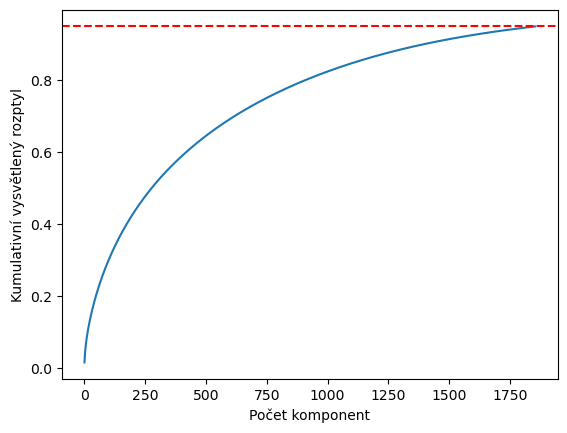

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [9]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
    # You can now use STFullyConnected_direct
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [10]:
import random 
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
param_space = {
    'dropout_frac': (0.0, 0.9),  # float range
    'patience': (10, 200),      # int range
    # Pro logaritmické rozložení hodnot:
    'tol': np.logspace(np.log10(1e-5), np.log10(1e-2), num=50).tolist(), # 50 logaritmicky rozložených hodnot
    'weight_decay': np.logspace(np.log10(1e-6), np.log10(1e-1), num=50).tolist(), # 50 logaritmicky rozložených hodnot
    'n_epochs': (200, 2000),    # int range
    'batch_size': [64, 128, 256, 512, 1024], # categorical
    'optimizer': [optim.AdamW, optim.RMSprop], # Nyní přímo funkce optimalizátorů
    'lr': [1.0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6], # categorical (diskrétní hodnoty)
    'neuron_layers': [ # Nyní přímo seznamy intů
        [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        [4096, 1024, 256, 64, 8],
        [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
        [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
        [200], [2000], [2000, 1000], [2000, 1000, 500],
        [1000, 50], [4000, 2000], [4000, 2000, 1000, 500], [4000, 2000, 2000, 500]
    ]
}
def generate_random_params(param_space_dict):
    params = {}
    for param_name, values in param_space_dict.items():
        if isinstance(values, tuple) and len(values) == 2:
            # Numerické rozsahy (int nebo float)
            min_val, max_val = values
            if isinstance(min_val, int) and isinstance(max_val, int):
                params[param_name] = random.randint(min_val, max_val)
            else: # float
                params[param_name] = random.uniform(min_val, max_val)
        elif isinstance(values, list):
            # Kategorické nebo diskrétní hodnoty (včetně logaritmicky rozložených a funkcí)
            params[param_name] = random.choice(values)
        else:
            # Pokud by byla definovaná jedna pevná hodnota (nemá se stát s tímto param_space)
            params[param_name] = values
    return params
def custom_objective(current_params, X_train, y_train, X_val, y_val):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = MultiLayerPerceptron(
        n_dim=X_train.shape[1],
        n_class=1,
        device=device,
        act_fun=F.selu,
        dropout_frac=current_params['dropout_frac'],
        patience=current_params['patience'],
        tol=current_params['tol'],
        weight_decay=current_params['weight_decay'],
        n_epochs=current_params['n_epochs'],
        neuron_layers=current_params['neuron_layers'],
        batch_size=current_params['batch_size'],
        optimizer=current_params['optimizer'], # Zde je stále objekt funkce
        lr=current_params['lr'],
        seed=69
        
    )
    
    model.fit(X_train, y_train, X_val, y_val)
    preds = model.predict(X_val)
    preds_bin = preds > 0.5

    y_val_np_actual = y_val
    
    f1 = f1_score(y_val_np_actual, preds_bin)
    acc = accuracy_score(y_val_np_actual, preds_bin)
    mcc = matthews_corrcoef(y_val_np_actual, preds_bin)

    return {'f1': f1, 'acc': acc, 'mcc': mcc}

In [11]:
import csv
import time
import os
import pandas as pd

num_iterations = 250

output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG/modelshyperparameter_tuning_results'
os.makedirs(output_dir, exist_ok=True)
csv_filename = os.path.join(output_dir, 'hERG_mlp_without_smote.csv')

all_param_names_for_csv = list(param_space.keys())
header = ['run_id', 'mcc', 'f1', 'acc', 'duration_seconds'] + all_param_names_for_csv

# --- Correctly determine last_run_id ---
last_run_id = 0  # Default if file is new or no valid run_ids found

if os.path.isfile(csv_filename):
    try:
        # Attempt to read the existing CSV
        df_temp = pd.read_csv(csv_filename)
        if not df_temp.empty and 'run_id' in df_temp.columns:
            # Convert 'run_id' to numeric, coercing errors to NaT/NaN, then drop them
            valid_run_ids = pd.to_numeric(df_temp['run_id'], errors='coerce').dropna()
            if not valid_run_ids.empty:
                last_run_id = valid_run_ids.max()
            else:
                print(f"Warning: 'run_id' column in '{csv_filename}' had no valid numeric data. Treating as if starting fresh for run numbering.")
                # If we decide the file is problematic and should be "reset" (header-wise)
                # We might want to ensure the header is written cleanly by pandas below.
                # For now, just last_run_id is 0.
        # If df_temp is empty (e.g., only a header), last_run_id remains 0.
    except pd.errors.EmptyDataError:
        # File exists but is completely empty. Create it with a header.
        print(f"File '{csv_filename}' exists but is empty. Creating with header.")
        pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
        last_run_id = 0
    except Exception as e:
        # Other errors during reading (e.g., malformed CSV)
        print(f"Error reading existing CSV '{csv_filename}': {e}. Will attempt to start fresh.")
        # Optionally, overwrite with a clean header if reading fails catastrophically
        try:
            pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
            print(f"Overwrote '{csv_filename}' with a new header due to read error.")
        except Exception as e_write:
            print(f"Could not even overwrite '{csv_filename}' with new header: {e_write}")
        last_run_id = 0
else:
    # File does not exist, create it with a header
    print(f"File '{csv_filename}' does not exist. Creating with header.")
    pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
    last_run_id = 0

# Ensure last_run_id is a proper integer
if pd.isna(last_run_id): # Checks for NaN
    print(f"Warning: last_run_id was NaN. Resetting to 0.")
    last_run_id = 0
last_run_id = int(last_run_id) # Convert to int

# --- Main processing loop ---
print(f"Bude vyzkoušeno {num_iterations} náhodných kombinací hyperparametrů. Výsledky se ukládají do {csv_filename}")
print(f"Starting new runs after existing highest run_id: {last_run_id}")

with open(csv_filename, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=header)
    # The header is now reliably written by pandas if the file was new/empty/corrupt.
    # So, `csv.DictWriter` should NOT write it again here.

    # The line `df_existing = pd.read_csv(csv_filename)` from your original script
    # (inside the `with open` block) is no longer needed for determining `last_run_id`.
    # It can be removed if not used for other purposes.

    for i in range(num_iterations):
        current_params = generate_random_params(param_space) # Make sure this function is defined
        start_time = time.time()

        current_processing_run_id = last_run_id + i + 1 # Use the correctly determined last_run_id

        print(f"\nProbíhá kombinace {current_processing_run_id}/{last_run_id + num_iterations}:")

        opt_name_for_print = getattr(current_params['optimizer'], '__name__', str(current_params['optimizer']))

        print(f"  Dropout: {current_params['dropout_frac']:.3f}, Patience: {current_params['patience']}, Tol: {current_params['tol']:.2e}, WD: {current_params['weight_decay']:.2e}, Epochs: {current_params['n_epochs']}")
        print(f"  BS: {current_params['batch_size']}, Opt: {opt_name_for_print}, LR: {current_params['lr']:.1e}")
        print(f"  Layers: {current_params['neuron_layers']}")

        metrics = custom_objective(current_params, X1, y1, X2, y2) # Make sure this is defined with X1,y1 etc.

        end_time = time.time()
        duration = end_time - start_time

        print(f"MCC: {metrics['mcc']:.4f}, F1: {metrics['f1']:.4f}, Accuracy: {metrics['acc']:.4f}, Doba trvání: {duration:.2f} s")

        result_entry = {
            'run_id': current_processing_run_id,
            'mcc': metrics['mcc'],
            'f1': metrics['f1'],
            'acc': metrics['acc'],
            'duration_seconds': duration
        }

        params_to_save = current_params.copy()
        params_to_save['optimizer'] = getattr(current_params['optimizer'], '__name__', str(current_params['optimizer']))
        params_to_save['neuron_layers'] = str(current_params['neuron_layers']) # Stringify for CSV

        result_entry.update(params_to_save)

        writer.writerow(result_entry)
        f.flush()

print(f"\nExperiment dokončen. Všechny výsledky jsou v: {csv_filename}")

# Final read for displaying results
results_df_final = pd.read_csv(csv_filename)
    # Attempt to convert run_id to numeric for sorting, handling potential errors if any NaNs slipped through.
results_df_final['run_id'] = pd.to_numeric(results_df_final['run_id'], errors='coerce')
results_df_final.dropna(subset=['run_id'], inplace=True) # Drop rows where run_id became NaN after coercion
results_df_final['run_id'] = results_df_final['run_id'].astype(int)

results_df_sorted = results_df_final.sort_values(by='mcc', ascending=False)
print("\nNejlepší výsledky z finálního souboru (seřazeno podle MCC):")
print(results_df_sorted.head())

Bude vyzkoušeno 250 náhodných kombinací hyperparametrů. Výsledky se ukládají do /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG/modelshyperparameter_tuning_results/hERG_mlp_without_smote.csv
Starting new runs after existing highest run_id: 1042

Probíhá kombinace 1043/1292:
  Dropout: 0.306, Patience: 129, Tol: 2.44e-03, WD: 6.25e-02, Epochs: 1129
  BS: 128, Opt: RMSprop, LR: 1.0e-03
  Layers: [4000, 2000, 1000, 500]
MCC: 0.3069, F1: 0.6984, Accuracy: 0.6585, Doba trvání: 381.30 s

Probíhá kombinace 1044/1292:
  Dropout: 0.393, Patience: 150, Tol: 9.54e-05, WD: 3.39e-05, Epochs: 1203
  BS: 128, Opt: RMSprop, LR: 1.0e-01
  Layers: [4000, 2000, 2000, 500]
MCC: 0.0000, F1: 0.7390, Accuracy: 0.5860, Doba trvání: 741.73 s

Probíhá kombinace 1045/1292:
  Dropout: 0.354, Patience: 134, Tol: 3.24e-03, WD: 2.33e-03, Epochs: 1016
  BS: 512, Opt: RMSprop, LR: 1.0e-02
  Layers: [4096, 1024, 256, 64, 8]
MCC: 0.0000, F1: 0.7390, Accuracy: 0.5860, Doba trvání: 156.49 s

Probíhá kombina

KeyboardInterrupt: 

In [12]:
if os.path.exists(csv_filename):
    #os.remove(csv_filename)
    print(f"Starý soubor '{csv_filename}' byl smazán.")

Starý soubor '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG/modelshyperparameter_tuning_results/hERG_mlp_without_smote.csv' byl smazán.


In [13]:
import os
print(os.getcwd())

/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG


In [14]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG/modelshyperparameter_tuning_results'
os.makedirs(output_dir, exist_ok=True)
csv_filename = os.path.join(output_dir, 'hERG_mlp_without_smote.csv')

In [15]:
print("\n--- SEKCE 2: NAČTENÍ NEJLEPŠÍCH HYPERPARAMETRŮ A TESTOVÁNÍ MODELU ---")

# 1. Načtení výsledků z CSV
results_df = pd.read_csv(csv_filename)

# 2. Vyhledání nejlepší sady hyperparametrů
# Předpokládáme, že optimalizujeme pro 'mcc' (Matthews Correlation Coefficient)
best_row = results_df.loc[results_df['mcc'].idxmax()]
best_params = {}

# Rekonstrukce parametrů z nejlepšího řádku CSV
for param_name in param_space.keys(): # Projdeme všechny klíče z původního param_space
    value_from_csv = best_row[param_name]
    
    if param_name == 'optimizer':
        # Převod jména optimalizátoru zpět na PyTorch objekt funkce
        if value_from_csv == "AdamW":
            best_params[param_name] = optim.AdamW
        elif value_from_csv == "RMSprop":
            best_params[param_name] = optim.RMSprop
    elif param_name == 'neuron_layers':
        # Převod řetězce "[...]" zpět na seznam intů
        import ast # Importujeme ast, pokud ještě není
        best_params[param_name] = ast.literal_eval(value_from_csv)
    else:
        # Ostatní parametry by měly být načteny přímo
        best_params[param_name] = value_from_csv

print("\n--- Nejlepší hyperparametry nalezené laděním: ---")
print(best_params)
print(f"Nejvyšší MCC z validace: {best_row['mcc']:.4f}")

# 3. Trénování finálního modelu s nejlepšími hyperparametry na celém trénovacím datasetu
# Obvykle se model trénuje na (X_train_tensor + X_val_tensor) pro finální model
# V našem případě, protože jsme si udělali explicitní train, val, test,
# budeme trénovat na X_train_val_tensor (tj. X_train_tensor + X_val_tensor).
# Pokud máte jen trénovací a testovací, trénujete na X_train_tensor.

print("\n--- Trénování finálního modelu s nejlepšími hyperparametry ---")
device = "cuda" if torch.cuda.is_available() else "cpu"

final_model = MultiLayerPerceptron(
    n_dim=X1.shape[1], # Použijeme dimenze z trénovací sady
    n_class=1, # Binární klasifikace
    device=device,
    act_fun=F.selu, # Předpokládáme stejnou aktivační funkci
    dropout_frac=best_params['dropout_frac'],
    patience=best_params['patience'],
    tol=best_params['tol'],
    weight_decay=best_params['weight_decay'],
    n_epochs=int(best_params['n_epochs']),
    neuron_layers=best_params['neuron_layers'],
    batch_size=int(best_params['batch_size']),
    optimizer=best_params['optimizer'],
    lr=best_params['lr'],
    seed=69, print_outputs=2
)

# Trénování na kombinované trénovací a validační sadě (X_train_val_tensor)
# Vhodnější je trénovat na X_train_tensor a X_val_tensor zvlášť a validovat,
# ale pro finální trénink s nejlepším modelem se často používá celý dostupný trénovací dataset.
# Zde použijeme původní X_train_tensor a y_train_tensor pro "trénování" a
# X_val_tensor a y_val_tensor pro "validaci" uvnitř fit metody,
# přesně jako v ladicí fázi.
# DŮLEŽITÉ: Pokud byste chtěl trénovat na celém trénovacím datasetu (X_train_val_tensor),
# museli byste spojit X_train_tensor a X_val_tensor do jednoho tenzoru pro trénink.
# Pro simulaci se držím toho, co už je nastaveno v custom_objective.
final_model.fit(X1, y1, X2, y2) 

print("\n--- Model byl trénován na trénovací a validační sadě ---")




--- SEKCE 2: NAČTENÍ NEJLEPŠÍCH HYPERPARAMETRŮ A TESTOVÁNÍ MODELU ---

--- Nejlepší hyperparametry nalezené laděním: ---
{'dropout_frac': 0.4902293235405122, 'patience': 110, 'tol': 0.0042919342601287, 'weight_decay': 0.0023299518105153, 'n_epochs': 1677, 'batch_size': 1024, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'lr': 0.0001, 'neuron_layers': [1000, 50]}
Nejvyšší MCC z validace: 0.4536

--- Trénování finálního modelu s nejlepšími hyperparametry ---
Epoch 1 | Train Loss: 0.5831 | Valid Loss: 0.5581 | MCC: 0.1682
Epoch 2 | Train Loss: 0.5435 | Valid Loss: 0.5435 | MCC: 0.2452
Epoch 3 | Train Loss: 0.5123 | Valid Loss: 0.5308 | MCC: 0.3006
Epoch 4 | Train Loss: 0.4817 | Valid Loss: 0.5196 | MCC: 0.3389
Epoch 5 | Train Loss: 0.4564 | Valid Loss: 0.5097 | MCC: 0.3568
Epoch 6 | Train Loss: 0.4313 | Valid Loss: 0.5011 | MCC: 0.3813
Epoch 7 | Train Loss: 0.4089 | Valid Loss: 0.4937 | MCC: 0.4012
Epoch 8 | Train Loss: 0.3888 | Valid Loss: 0.4877 | MCC: 0.4172
Epoch 9 | Train Loss: 0.

In [16]:
print(matthews_corrcoef(final_model.predict(X2) >0.5, y2))
best_params

0.4320954144053697


{'dropout_frac': 0.4902293235405122,
 'patience': 110,
 'tol': 0.0042919342601287,
 'weight_decay': 0.0023299518105153,
 'n_epochs': 1677,
 'batch_size': 1024,
 'optimizer': torch.optim.adamw.AdamW,
 'lr': 0.0001,
 'neuron_layers': [1000, 50]}

In [17]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
    # You can now use STFullyConnected_direct
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [18]:

final_model = MultiLayerPerceptron(
    n_dim=X1.shape[1], # Použijeme dimenze z trénovací sady
    n_class=1, # Binární klasifikace
    device=device,
    #is_reg=False,
    #gpus= None,
    act_fun=F.selu, # Předpokládáme stejnou aktivační funkci
    dropout_frac=best_params['dropout_frac'],
    patience=best_params['patience'],
    tol=best_params['tol'],
    weight_decay=best_params['weight_decay'],
    n_epochs=int(best_params['n_epochs']),
    neuron_layers=best_params['neuron_layers'],
    batch_size=int(best_params['batch_size']),
    optimizer=best_params['optimizer'],
    lr=best_params['lr'],
    seed=69, print_outputs=2
)

In [19]:
final_model.fit(X1, y1, X2, y2)


Epoch 1 | Train Loss: 0.5831 | Valid Loss: 0.5581 | MCC: 0.1682
Epoch 2 | Train Loss: 0.5435 | Valid Loss: 0.5435 | MCC: 0.2452
Epoch 3 | Train Loss: 0.5123 | Valid Loss: 0.5308 | MCC: 0.3006
Epoch 4 | Train Loss: 0.4817 | Valid Loss: 0.5196 | MCC: 0.3389
Epoch 5 | Train Loss: 0.4564 | Valid Loss: 0.5097 | MCC: 0.3568
Epoch 6 | Train Loss: 0.4313 | Valid Loss: 0.5011 | MCC: 0.3813
Epoch 7 | Train Loss: 0.4089 | Valid Loss: 0.4937 | MCC: 0.4012
Epoch 8 | Train Loss: 0.3888 | Valid Loss: 0.4877 | MCC: 0.4172
Epoch 9 | Train Loss: 0.3693 | Valid Loss: 0.4831 | MCC: 0.4214
Epoch 10 | Train Loss: 0.3488 | Valid Loss: 0.4798 | MCC: 0.4281
Epoch 11 | Train Loss: 0.3346 | Valid Loss: 0.4779 | MCC: 0.4321
Epoch 12 | Train Loss: 0.3172 | Valid Loss: 0.4775 | MCC: 0.4338
Epoch 13 | Train Loss: 0.3010 | Valid Loss: 0.4784 | MCC: 0.4345
Epoch 14 | Train Loss: 0.2899 | Valid Loss: 0.4807 | MCC: 0.4317
Epoch 15 | Train Loss: 0.2762 | Valid Loss: 0.4843 | MCC: 0.4322
Epoch 16 | Train Loss: 0.2637 | Va

(MultiLayerPerceptron(
   (layers): ModuleList(
     (0): Linear(in_features=1854, out_features=1000, bias=True)
     (1): Linear(in_features=1000, out_features=50, bias=True)
     (2): Linear(in_features=50, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.4902293235405122, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 10)

In [20]:
pred = final_model.predict(X3) >0.5 
display(matthews_corrcoef(pred, y3))

0.3718622759772372

In [21]:

model = STFullyConnected(
        n_dim=X1.shape[1],
        n_class=1,
        device="cuda",
        act_fun=F.selu,
        dropout_frac=0.7587301567075606,
        patience=0.00010905325401069917,
        tol=0,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=0.024542235145206714,
        n_epochs=403,
        neuron_layers= [200],  # Použití neuron_layers_size
        batch_size=128,
        optimizer=optim.AdamW,
        lr=1e-06,
    print_outputs= 2
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

NameError: name 'STFullyConnected' is not defined

In [37]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

0.5764386444017885

In [38]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [39]:
display(mcc) # 0.17324800323685596

0.30311535423773306

In [35]:
study_4.best_params

{'dropout_frac': 0.7587301567075606,
 'patience': 147,
 'tol': 0.00010905325401069917,
 'weight_decay': 0.024542235145206714,
 'n_epochs': 403,
 'batch_size': 128,
 'optimizer': 'AdamW',
 'lr': 1e-06,
 'neuron_layers_size': '[200]'}